d6t22lhr01qoqoiruqlgd6t22lhr01qoqoiruqm0


[*********************100%***********************]  1 of 1 completed


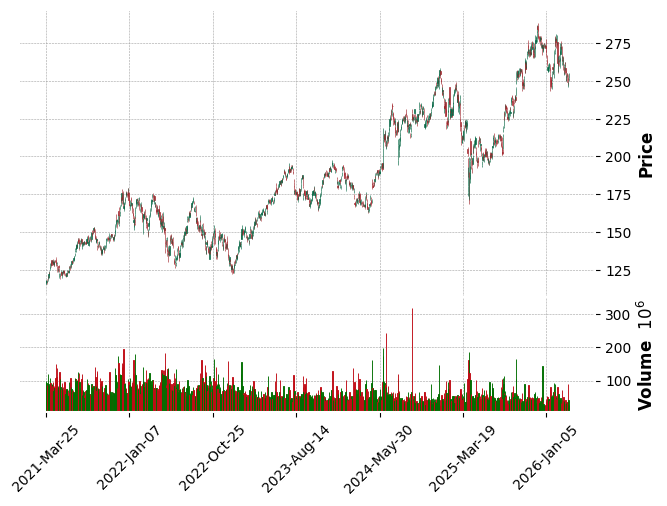

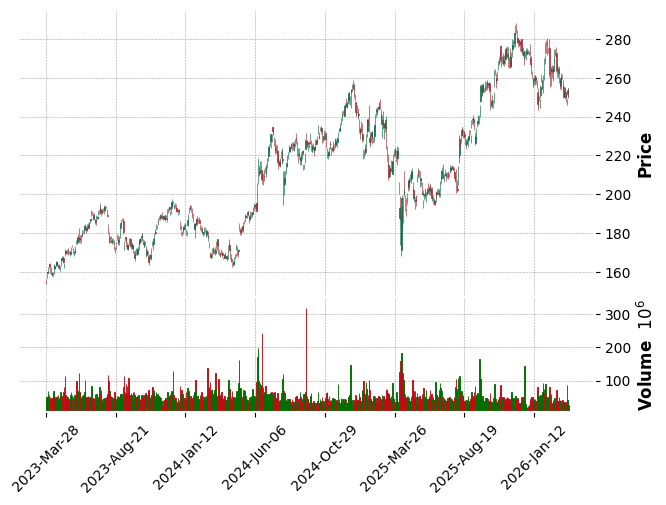

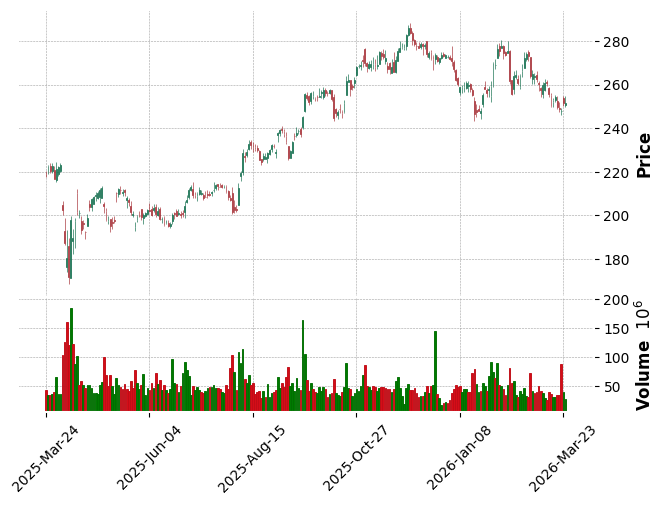

In [1]:
%load_ext autoreload
%autoreload 1
%aimport fundamentals

import finnhub
import pandas as pd
import json
from fundamentals import Fundamentals
import numpy as np
from itables import init_notebook_mode, options
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
import datetime as dt
import mplfinance as mpf
import ipynbname
init_notebook_mode(all_interactive=True)
options.style = "table-layout:auto; width:50%;"
plt.style.use('dark_background')
pd.set_option('display.float_format', '{:.2f}'.format)

# Setup client
# ASIX
name = ipynbname.name().strip('.ipynb').upper()
thirtyday = dt.datetime.now() - dt.timedelta(days=90)
Fun = Fundamentals(name, thirtyday.strftime('%Y-%m-%d'), dt.datetime.now().strftime('%Y-%m-%d'))

historical = Fun.get_history()
historical.columns = historical.columns.get_level_values(0)
mpf.plot(historical, type='candle', style='charles',volume=True,warn_too_much_data=10000000)
mpf.plot(historical.iloc[-750:], type='candle', style='charles',volume=True,warn_too_much_data=10000000)
mpf.plot(historical.iloc[-252:], type='candle', style='charles',volume=True)

In [2]:
funds = Fun.get_fundamentals()

funds

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


149.6825


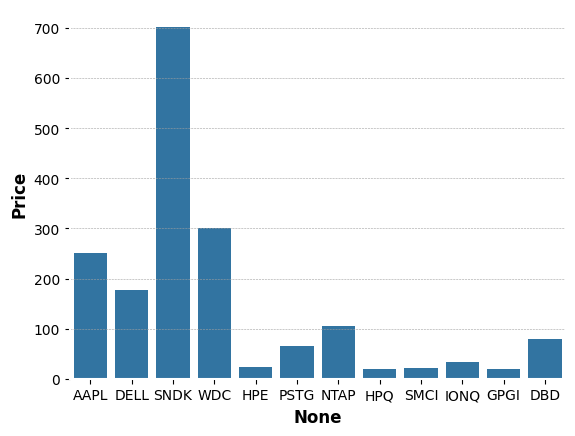

In [3]:
peers, avg_price = Fun.get_peers()
print(avg_price)
sns.barplot(x=peers.index, y=peers['Price'])
plt.show()

In [4]:
fairValues = Fun.caculateFairValues()

fairValues.head()

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


In [5]:
other_metrics = Fun.get_other_metric()

other_metrics.head()

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


In [6]:
insider_sentiment = Fun.get_insider_sentiment()
print(f"{insider_sentiment[0]}:")
print("")
print(insider_sentiment[1])

insider_signal:

Bearish (Net Sell): -25,796 shares


In [7]:
news = Fun.get_news()

for x in news:
    print(x['datetime'])
    print(x['headline'])
    print(x['summary'])
    print(x['url'])
    print("")

2026-03-24 16:07:19
Did AirPods Max 2’s Apple Intelligence Push Just Shift Apple’s (AAPL) Investment Narrative?
Earlier in March, Apple announced AirPods Max 2, an upgraded over-ear headset with stronger noise cancellation, lossless USB-C audio, creator-focused tools, and new AI-enabled features powered by its H2 chip. The launch extends Apple Intelligence beyond iPhone and Mac into premium audio, reinforcing Apple’s ecosystem and adding fresh use cases for professionals and everyday users. We’ll now examine how this extension of Apple Intelligence into AirPods Max 2 could influence the company’s...
https://finnhub.io/api/news?id=2965d66923700b57a047d2d38fafd9d3b031719e20a8528ff3dfbe6d884b699c

2026-03-24 16:05:00
1 Brilliant Growth Stock to Buy Before It Joins Nvidia, Alphabet, and Apple in the $3 Trillion Club
Meta Platforms is overhauling the entire social media experience using artificial intelligence.
https://finnhub.io/api/news?id=ea2a1f2744194777657ddfe4cb7453e4145c89b1e2c654218

Average Weighted EPS: 0.6601
Lower Standard Deviation: 0.06955596228218719
Upper Standard Deviation: 1.2506440377178127
Total Debt/Total Equity: 1.0263


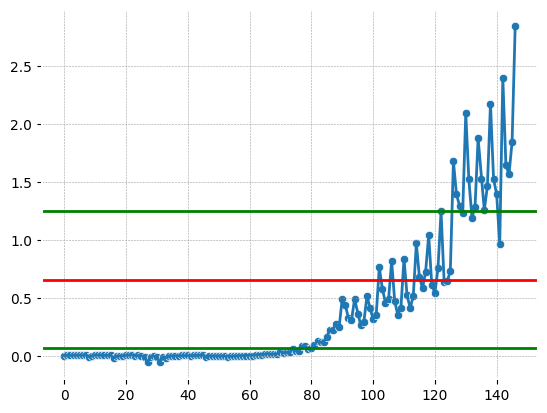

In [8]:
inflect = Fun.get_inflections()

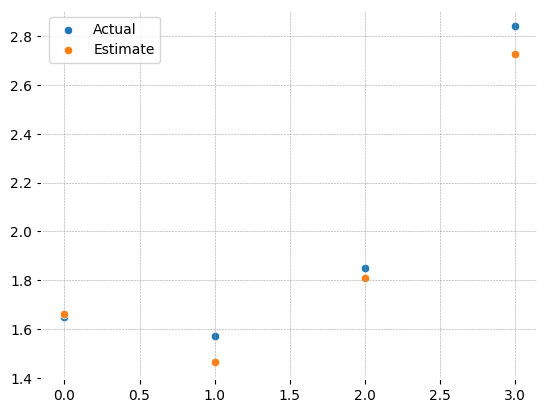

In [9]:
surprise = Fun.eps_surprise()

2025-09-30   416161000000.00
2024-09-30   391035000000.00
2023-09-30   383285000000.00
2022-09-30   394328000000.00
2021-09-30               NaN
Name: Total Revenue, dtype: float64
Revenue: [2.60174e+11 2.74515e+11 3.65817e+11 3.94328e+11 3.83285e+11 3.91035e+11
 4.16161e+11]


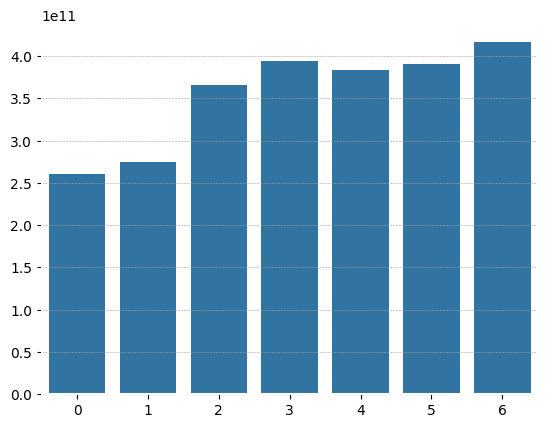

In [10]:
revenue = Fun.revenue_growth()